# Praktikum 1.2: EDA Korelasi Gizi dengan Label Nutri-Score

Melanjutkan `5054251024_Muhammad-Irzam-Hafis-Fabiansyah_Tugas_Scrapping.ipynb`. Jalankan notebook tersebut lebih dulu agar `data/off_nutrition.csv` tersedia.

**Pertanyaan yang dijawab:** zat gizi apa yang paling menentukan sebuah produk mendapat label Nutri-Score `a` (terbaik) atau `e` (terburuk)?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_FILE = Path("data/off_nutrition.csv")

NUTRIENTS = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "fruits-vegetables-nuts-estimate-from-ingredients_100g",
]

if not RESULT_FILE.exists():
    raise FileNotFoundError(f"{RESULT_FILE} belum ada, jalankan 5054251024_Muhammad-Irzam-Hafis-Fabiansyah_Tugas_Scrapping.ipynb dulu.")

df_mentah = pd.read_csv(RESULT_FILE, dtype={"code": str})
print("Ukuran:", df_mentah.shape)
df_mentah.head()

Ukuran: (1999, 15)


,code,product_name,brands,nutriscore_grade,nutriscore_score,nova_group,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,6111035000430,Sidi Ali,سيدي علي,a,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00
1,6111242100992,Perly,Jaouda,a,0,3.0,97.0,3.0,0.0,9.4,9.4,0.0,8.0,0.00000,6.85
2,6111035000058,Eau minérale naturelle,sidi ali,a,0,1.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.00600,0.00
3,6111035002175,Sidi Ali,Sidi Ali,a,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
4,3274080005003,isabelle,Cristaline,a,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00275,0.00


## 1. Pemahaman dataset

Sebelum dibersihkan, lihat dulu kondisi mentahnya: ukuran, jumlah nilai terisi per kolom, dan
tipe data yang ditebak pandas lewat `.info()` dan `.dtypes`.

In [2]:
print("Ukuran (baris, kolom):", df_mentah.shape)
df_mentah.info()

print("\nTipe data hasil tebakan pandas:")
print(df_mentah.dtypes)

Ukuran (baris, kolom): (1999, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 15 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   code                                                   1999 non-null   str    
 1   product_name                                           1963 non-null   str    
 2   brands                                                 1963 non-null   str    
 3   nutriscore_grade                                       1999 non-null   str    
 4   nutriscore_score                                       1999 non-null   int64  
 5   nova_group                                             1862 non-null   float64
 6   energy-kcal_100g                                       1903 non-null   float64
 7   fat_100g                                               1898 non-null   float64
 8   saturated-fat_100g       

Tipe data pandas (`object`, `float64`) belum tentu sama dengan tipe atribut secara statistik.
`nova_group` misalnya terbaca `float64` padahal isinya peringkat 1–4, bukan besaran yang boleh
dirata-rata. Karena itu tiap kolom diberi label manual:

- **nominal**: kategori tanpa urutan (kode, nama, merek)
- **ordinal**: kategori berurutan tapi jaraknya tidak setara (`a` < `b` < `c` < `d` < `e`)
- **numerik**: besaran yang boleh dihitung; **diskret** kalau cacahan bilangan bulat,
  **kontinu** kalau bisa bernilai pecahan

In [3]:
ATTR_TYPES = {
    "code": ("nominal", "barcode produk, identitas unik tanpa urutan"),
    "product_name": ("nominal", "nama produk, teks bebas"),
    "brands": ("nominal", "merek produk, teks bebas"),
    "nutriscore_grade": ("ordinal", "label a-e, berurutan tapi jaraknya tidak setara"),
    "nutriscore_score": ("numerik diskret", "skor gabungan, bilangan bulat"),
    "nova_group": ("ordinal", "tingkat pengolahan 1-4, berurutan tapi jaraknya tidak setara"),
    "energy-kcal_100g": ("numerik kontinu", "kkal per 100 g"),
}
ATTR_TYPES.update(
    {kolom: ("numerik kontinu", "gram per 100 g") for kolom in NUTRIENTS if kolom not in ATTR_TYPES}
)

tipe = pd.DataFrame(ATTR_TYPES, index=["tipe_atribut", "keterangan"]).T
tipe.index.name = "kolom"
tipe

,tipe_atribut,keterangan
kolom,,
code,nominal,"barcode produk, identitas unik tanpa urutan"
product_name,nominal,"nama produk, teks bebas"
brands,nominal,"merek produk, teks bebas"
nutriscore_grade,ordinal,"label a-e, berurutan tapi jaraknya tidak setara"
nutriscore_score,numerik diskret,"skor gabungan, bilangan bulat"
nova_group,ordinal,"tingkat pengolahan 1-4, berurutan tapi jarakny..."
energy-kcal_100g,numerik kontinu,kkal per 100 g
fat_100g,numerik kontinu,gram per 100 g
saturated-fat_100g,numerik kontinu,gram per 100 g


## 2. Pembersihan data

Open Food Facts diisi sukarela oleh kontributor, jadi wajar ada nilai kosong, duplikat, dan angka mustahil (misalnya lemak 900 g per 100 g). Langkah pembersihan:

1. **duplikat:** satu produk (`code`) bisa muncul di lebih dari satu halaman
2. **tipe data:** semua kolom gizi dipaksa numerik, teks yang gagal jadi `NaN`
3. **rentang wajar:** massa per 100 g tidak mungkin negatif atau melebihi 100 g, dan energi dibatasi 900 kkal (lemak murni ≈ 900 kkal/100 g). Nilai di luar itu kemungkinan besar salah input, bukan outlier asli, jadi dijadikan `NaN` karena kolom lain di baris yang sama masih berguna.

In [4]:
df = df_mentah.drop_duplicates(subset="code").copy()

for kolom in NUTRIENTS + ["nutriscore_score", "nova_group"]:
    df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

# Buang nilai tidak masuk akal
batas_atas = {kolom: 100.0 for kolom in NUTRIENTS}
batas_atas["energy-kcal_100g"] = 900.0

for kolom, atas in batas_atas.items():
    df.loc[~df[kolom].between(0, atas), kolom] = np.nan

# Label adalah variabel target
df = df.dropna(subset=["nutriscore_grade"])

# Nutri-Score bersifat ordinal
GRADES = ["a", "b", "c", "d", "e"]
df["nutriscore_grade"] = pd.Categorical(df["nutriscore_grade"], categories=GRADES, ordered=True)
df["grade_ordinal"] = df["nutriscore_grade"].cat.codes + 1  # a=1 s.d. e=5, makin besar makin buruk

print("Setelah dibersihkan:", df.shape)
print("\nSebaran label:")
print(df["nutriscore_grade"].value_counts().sort_index())
print("\nKelengkapan kolom gizi:")
print(df[NUTRIENTS].notna().mean().sort_values(ascending=False).round(3))

Setelah dibersihkan: (1999, 16)

Sebaran label:
nutriscore_grade
a    400
b    400
c    400
d    400
e    399
Name: count, dtype: int64

Kelengkapan kolom gizi:
salt_100g                                                0.958
energy-kcal_100g                                         0.950
proteins_100g                                            0.949
fat_100g                                                 0.949
sugars_100g                                              0.948
saturated-fat_100g                                       0.948
carbohydrates_100g                                       0.945
fruits-vegetables-nuts-estimate-from-ingredients_100g    0.879
fiber_100g                                               0.733
dtype: float64


## 3. Statistik deskriptif dan kualitas data

Pada jarak antara median dan rata-rata pada kolom seperti `sugars_100g`: kalau rata-rata jauh di atas median, sebarannya miring ke kanan (banyak produk berkadar rendah, sedikit produk berkadar sangat tinggi). Ini alasan utama memilih korelasi berbasis peringkat
di bagian berikutnya.

In [5]:
stats = df[NUTRIENTS].describe().T
stats["modus"] = df[NUTRIENTS].mode().iloc[0]  # nilai paling sering muncul
stats.round(2)  # kolom 50% adalah median

,count,mean,std,min,25%,50%,75%,max,modus
energy-kcal_100g,1899.0,300.26,209.49,0.0,98.51,289.00,456.00,900.0,0.0
fat_100g,1897.0,16.22,20.21,0.0,1.90,8.30,23.00,100.0,0.0
saturated-fat_100g,1895.0,5.45,8.38,0.0,0.40,1.70,7.20,60.0,0.0
carbohydrates_100g,1890.0,29.96,27.69,0.0,4.50,18.18,57.50,100.0,0.0
sugars_100g,1896.0,11.44,16.28,0.0,1.10,4.40,15.00,100.0,0.0
fiber_100g,1465.0,4.18,4.69,0.0,0.50,3.00,6.50,66.0,0.0
proteins_100g,1898.0,7.42,6.62,0.0,2.70,6.70,9.80,75.0,0.0
salt_100g,1916.0,0.66,1.61,0.0,0.03,0.30,0.95,44.6,0.0
fruits-vegetables-nuts-estimate-from-ingredients_100g,1757.0,13.73,26.22,0.0,0.00,0.00,13.00,100.0,0.0


### Nilai yang hilang per atribut

Hitung kekosongan untuk **semua** kolom, bukan cuma kolom gizi: kolom metadata seperti
`product_name` dan `nova_group` juga bisa kosong dan itu memengaruhi bagian mana dari analisis
yang masih bisa dipakai.

In [6]:
hilang = pd.DataFrame({
    "jumlah_hilang": df.isna().sum(),
    "persen_hilang": (df.isna().mean() * 100).round(1),
})
hilang.sort_values("jumlah_hilang", ascending=False)

,jumlah_hilang,persen_hilang
fiber_100g,534,26.7
fruits-vegetables-nuts-estimate-from-ingredients_100g,242,12.1
nova_group,137,6.9
carbohydrates_100g,109,5.5
saturated-fat_100g,104,5.2
sugars_100g,103,5.2
fat_100g,102,5.1
proteins_100g,101,5.1
energy-kcal_100g,100,5.0
salt_100g,83,4.2


**Penanganannya:** baris tidak dibuang. Tiap korelasi dihitung dengan pasangan data yang
tersedia saja (`pandas` otomatis mengabaikan `NaN`), jadi baris yang kosong di satu kolom masih
menyumbang informasi lewat kolom lain. Kolom `n_data` di tabel korelasi nanti mencatat berapa
banyak data yang benar-benar dipakai tiap kolom. Satu-satunya yang wajib ada adalah
`nutriscore_grade` karena itu variabel targetnya, dan barisnya sudah di-`dropna` saat pembersihan.

### Frekuensi atribut kategorikal

In [7]:
for col in ["nutriscore_grade", "nova_group"]:
    print(f"Frekuensi {col}:")
    print(df[col].value_counts(dropna=False).sort_index())
    print()

print("10 merek terbanyak (brands):")
print(df["brands"].value_counts().head(10))

Frekuensi nutriscore_grade:
nutriscore_grade
a    400
b    400
c    400
d    400
e    399
Name: count, dtype: int64

Frekuensi nova_group:
nova_group
1.0     226
2.0      63
3.0     454
4.0    1119
NaN     137
Name: count, dtype: int64

10 merek terbanyak (brands):
brands
Bjorg            58
Gerblé           46
Jaouda           37
Danone           33
Hacendado        31
Fleury Michon    30
Barilla          21
alpro            20
Bonne Maman      20
Harrys           18
Name: count, dtype: int64


### Deteksi outlier

Pembersihan tadi hanya membuang nilai yang **mustahil** (negatif atau di atas 100 g per 100 g);
yang tersisa masih bisa mengandung nilai ekstrem yang sah. Deteksinya pakai aturan IQR:
nilai di luar `Q1 − 1.5·IQR` sampai `Q3 + 1.5·IQR` ditandai sebagai outlier.

In [8]:
def cnt_outlier(kolom: pd.Series) -> pd.Series:
    nilai = kolom.dropna()
    q1, q3 = nilai.quantile([0.25, 0.75])
    iqr = q3 - q1
    bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    pencilan = (nilai < bawah) | (nilai > atas)
    return pd.Series({
        "batas_bawah": round(bawah, 2),
        "batas_atas": round(atas, 2),
        "jumlah_outlier": int(pencilan.sum()),
        "persen_outlier": round(pencilan.mean() * 100, 1),
    })



outlier = df[NUTRIENTS].apply(cnt_outlier).T
outlier["jumlah_outlier"] = outlier["jumlah_outlier"].astype(int)
outlier.sort_values("persen_outlier", ascending=False)

,batas_bawah,batas_atas,jumlah_outlier,persen_outlier
fruits-vegetables-nuts-estimate-from-ingredients_100g,-19.50,32.50,251,14.3
sugars_100g,-19.75,35.85,182,9.6
saturated-fat_100g,-9.80,17.40,151,8.0
proteins_100g,-7.95,20.45,125,6.6
fat_100g,-29.75,54.65,101,5.3
salt_100g,-1.34,2.32,53,2.8
fiber_100g,-8.50,15.50,31,2.1
energy-kcal_100g,-437.73,992.24,0,0.0
carbohydrates_100g,-75.00,137.00,0,0.0


**Penanganannya:** outlier ini **dibiarkan**, tidak dibuang maupun dipangkas. Alasannya nilai
seperti lemak 100 g per 100 g (minyak goreng) atau garam 44 g per 100 g (garam meja) memang
produk nyata, bukan salah input — yang salah input sudah disaring di tahap pembersihan.
Membuangnya justru menghapus produk grade `e` yang paling informatif. Pengaruhnya pada analisis
juga sudah diantisipasi: seluruh korelasi memakai **Spearman** yang bekerja atas peringkat, dan
ringkasan per grade memakai **median** — keduanya tidak tertarik oleh nilai ekstrem.

## 4. Visualisasi univariat

Sebelum melihat hubungan antar atribut, lihat dulu sebaran tiap atribut sendiri-sendiri:
histogram untuk kolom numerik, bar chart untuk kolom kategorikal.

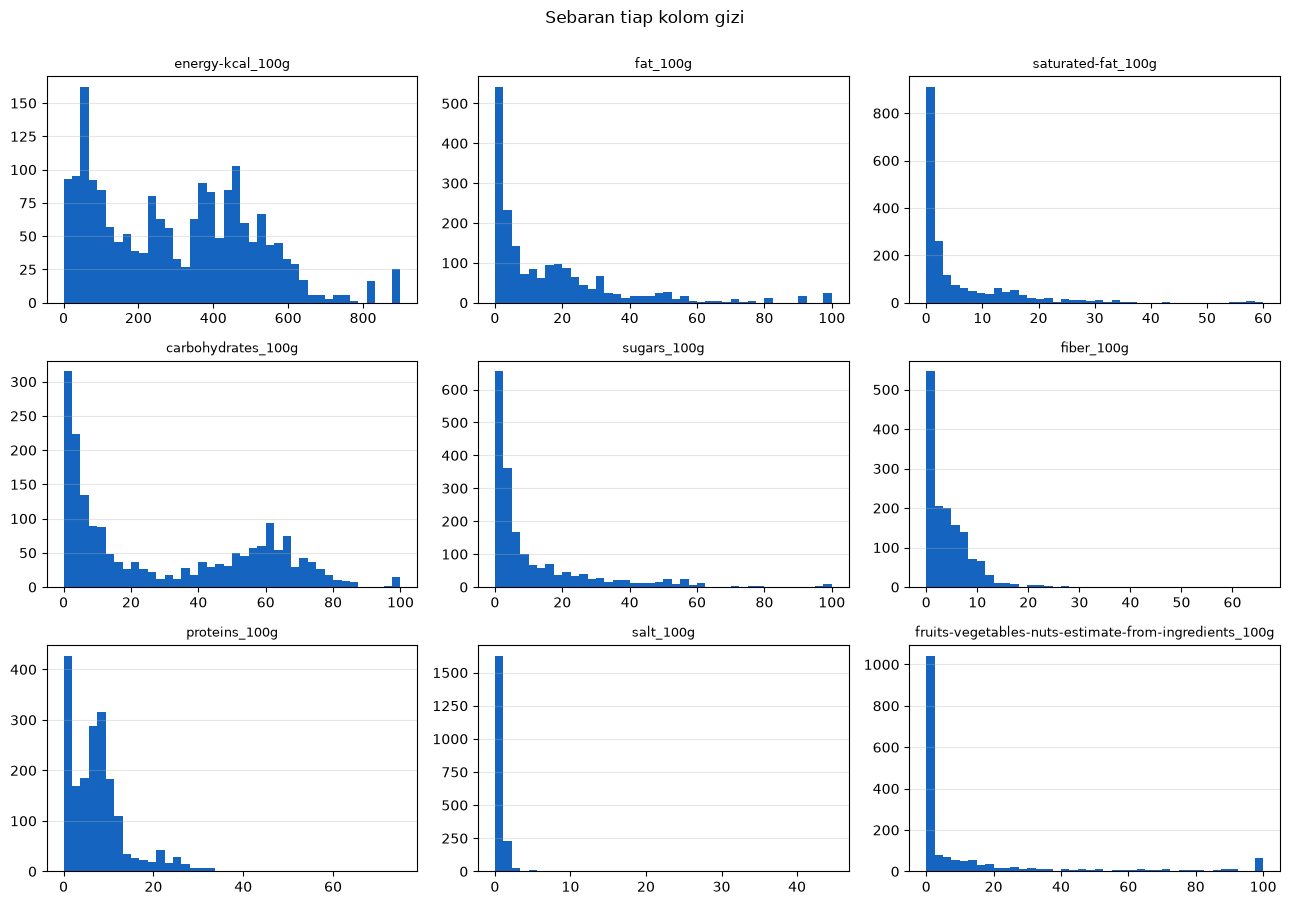

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, kolom in zip(axes.flat, NUTRIENTS):
    ax.hist(df[kolom].dropna(), bins=40, color="#1565c0")
    ax.set_title(kolom, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Sebaran tiap kolom gizi", y=1.0)
fig.tight_layout()
plt.show()

Hampir semua kolom gizi menumpuk di dekat nol dengan ekor panjang ke kanan — persis kemiringan
yang terbaca dari jarak mean vs median di Tabel statistik deskriptif. `energy-kcal_100g` paling
menyebar karena satuannya kkal, sedangkan `fruits-vegetables-nuts-estimate…` menumpuk ekstrem di
0 (mayoritas produk olahan tidak mengandung buah/sayur/kacang sama sekali). Bentuk miring begini
yang membuat Pearson dan rata-rata kurang cocok dipakai di bagian berikutnya.

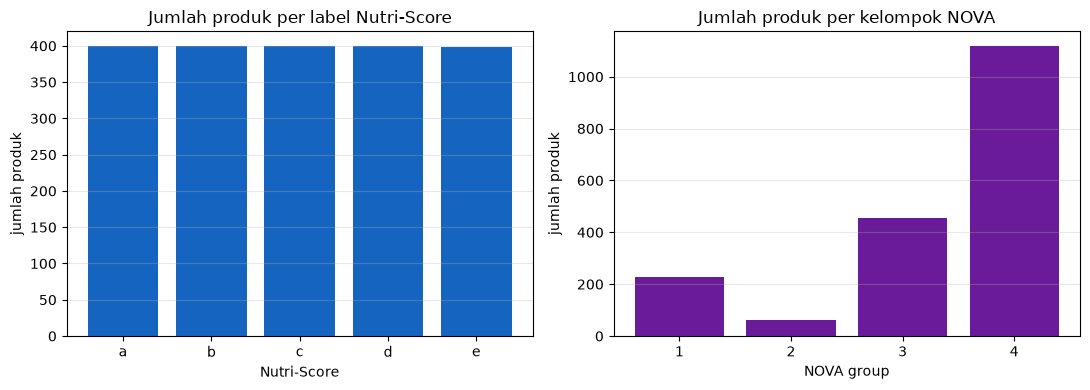

In [10]:
jml_grade = df["nutriscore_grade"].value_counts().sort_index()
jml_nova = df["nova_group"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(jml_grade.index.astype(str), jml_grade.values, color="#1565c0")
axes[0].set_title("Jumlah produk per label Nutri-Score")
axes[0].set_xlabel("Nutri-Score")

axes[1].bar(jml_nova.index.astype(int).astype(str), jml_nova.values, color="#6a1b9a")
axes[1].set_title("Jumlah produk per kelompok NOVA")
axes[1].set_xlabel("NOVA group")

for ax in axes:
    ax.set_ylabel("jumlah produk")
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

Sebaran label sengaja dibuat berimbang (~400 produk tiap grade) karena scraping-nya memfilter per
grade, jadi bar chart kiri rata — ini rancangan sampel, bukan temuan. Sebaliknya `nova_group`
tidak difilter, dan hasilnya miring ke NOVA 4 (produk ultra-olahan), yang wajar karena basis data
Open Food Facts didominasi produk kemasan.

## 5. Korelasi gizi dengan label

`grade_ordinal` adalah peringkat (a=1 s.d. e=5), bukan besaran yang jaraknya setara, sehingga korelasi yang tepat adalah **Spearman** (berbasis peringkat), bukan Pearson. Spearman juga tahan terhadap sebaran gizi yang miring seperti terlihat di atas.

Tanda korelasi dibaca begini:

- **positif** → makin tinggi kandungannya, makin buruk labelnya (bergerak ke `e`)
- **negatif** → makin tinggi kandungannya, makin baik labelnya (bergerak ke `a`)

In [11]:
corr = (
    df[NUTRIENTS + ["grade_ordinal"]]
    .corr(method="spearman", numeric_only=True)["grade_ordinal"]
    .drop("grade_ordinal")
    .sort_values()
)

summary = pd.DataFrame({
    "spearman_vs_grade": corr.round(3),
    "n_data": df[corr.index].notna().sum(),
})
summary["arah"] = np.where(summary["spearman_vs_grade"] > 0, "memperburuk label", "memperbaiki label")
summary

,spearman_vs_grade,n_data,arah
proteins_100g,-0.139,1898,memperbaiki label
fiber_100g,-0.122,1465,memperbaiki label
fruits-vegetables-nuts-estimate-from-ingredients_100g,-0.047,1757,memperbaiki label
salt_100g,0.173,1916,memperburuk label
carbohydrates_100g,0.233,1890,memperburuk label
fat_100g,0.394,1897,memperburuk label
energy-kcal_100g,0.397,1899,memperburuk label
saturated-fat_100g,0.473,1895,memperburuk label
sugars_100g,0.502,1896,memperburuk label


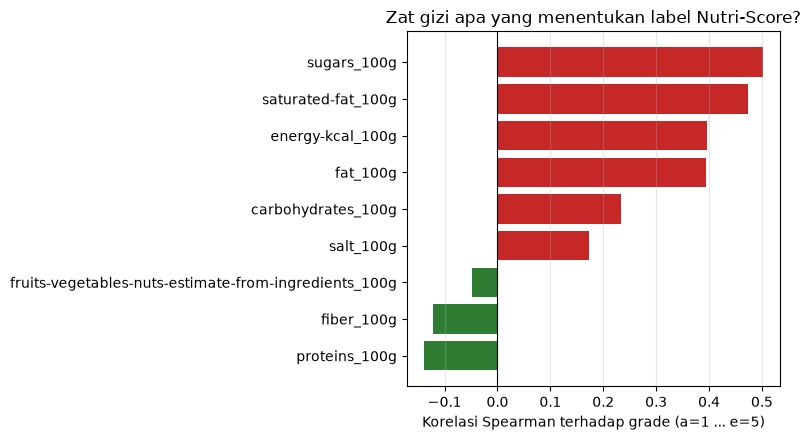

In [12]:
warna = ["#2e7d32" if nilai < 0 else "#c62828" for nilai in corr]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(corr.index, corr.values, color=warna)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Korelasi Spearman terhadap grade (a=1 ... e=5)")
ax.set_title("Zat gizi apa yang menentukan label Nutri-Score?")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Bentuk hubungannya

Korelasi meringkas arah hubungan menjadi satu angka. Tabel dan boxplot berikut menunjukkan
bentuknya: apakah benar naik monoton dari `a` ke `e`, atau justru mendatar di grade tengah.
Median dipakai, bukan rata-rata, karena alasan kemiringan sebaran tadi.

In [13]:
m = df.groupby("nutriscore_grade", observed=True)[NUTRIENTS].median().round(2)
m.insert(0, "jumlah_produk", df["nutriscore_grade"].value_counts().sort_index())
m

,jumlah_produk,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
nutriscore_grade,,,,,,,,,,
a,400,139.0,2.8,0.5,8.00,2.60,4.4,9.70,0.10,0.00
b,400,155.5,3.2,1.0,8.17,2.30,2.8,5.40,0.18,2.50
c,400,283.0,8.0,1.8,16.75,4.50,3.9,7.00,0.49,1.75
d,400,345.0,19.0,4.8,24.00,6.50,3.0,6.95,0.75,0.00
e,399,484.0,24.0,9.0,50.86,28.65,2.5,6.00,0.26,0.00


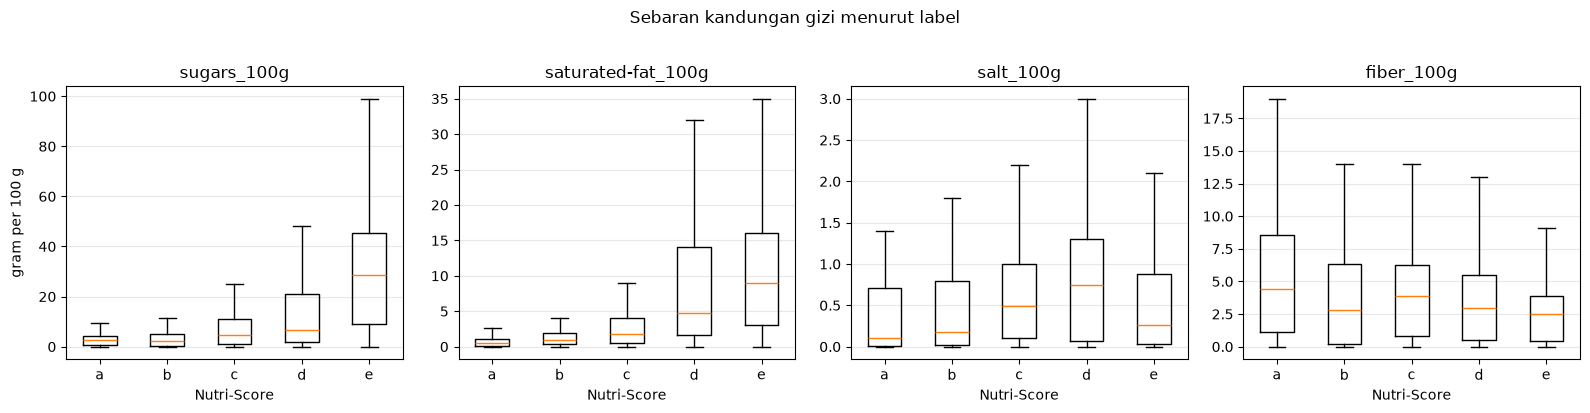

In [14]:
highlights = ["sugars_100g", "saturated-fat_100g", "salt_100g", "fiber_100g"]

fig, axes = plt.subplots(1, len(highlights), figsize=(16, 4))
for ax, col in zip(axes, highlights):
    data = [df.loc[df["nutriscore_grade"] == g, col].dropna() for g in GRADES]
    ax.boxplot(data, tick_labels=GRADES, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("Nutri-Score")
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("gram per 100 g")
fig.suptitle("Sebaran kandungan gizi menurut label", y=1.02)
fig.tight_layout()
plt.show()

## 7. Korelasi antar zat gizi

Kolom-kolom gizi juga saling berkorelasi (misalnya lemak dengan lemak jenuh, atau energi
dengan hampir semuanya). Ini penting diketahui sebelum dipakai sebagai fitur model: fitur
yang sangat berkorelasi membawa informasi yang sama, sehingga salah satunya bisa dibuang.

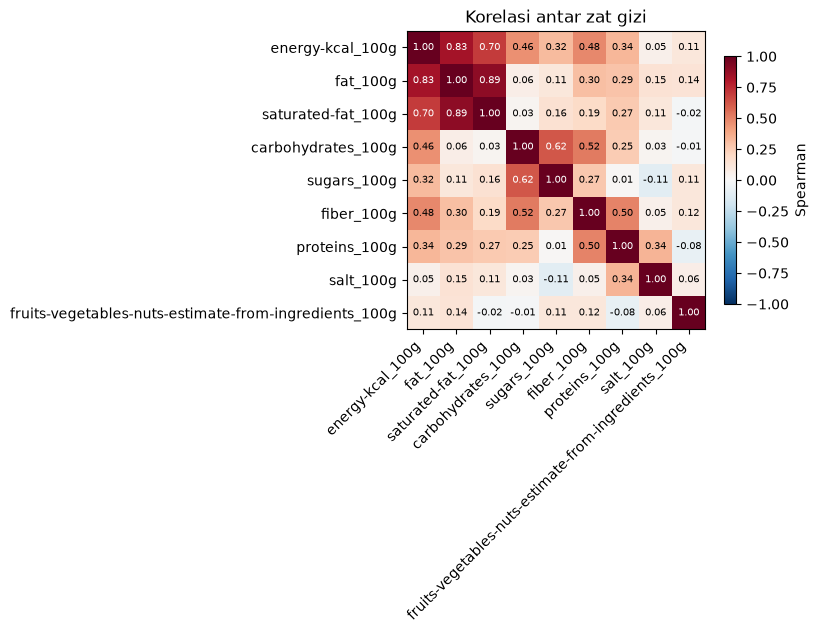

In [15]:
matrix = df[NUTRIENTS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
img = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(matrix)), matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix)), matrix.index)

for i in range(len(matrix)):
    for j in range(len(matrix)):
        nilai = matrix.iat[i, j]
        ax.text(j, i, f"{nilai:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(nilai) > 0.55 else "black")

fig.colorbar(img, ax=ax, shrink=0.8, label="Spearman")
ax.set_title("Korelasi antar zat gizi")
fig.tight_layout()
plt.show()

## 8. Kesimpulan

In [16]:
terkuat = corr.abs().sort_values(ascending=False)

print("Zat gizi paling menentukan label (|Spearman| terbesar):")
for col in terkuat.index[:4]:
    rate = corr[col]
    arah = "grade memburuk" if rate > 0 else "grade membaik"
    print(f"  {col:<50} {rate:+.3f}  → makin tinggi, {arah}")

# DataFrame.corr memakai peringkat internal, jadi tidak membutuhkan scipy.
konsistensi = df[["grade_ordinal", "nutriscore_score"]].corr(method="spearman").iat[0, 1]
print(f"\nKorelasi grade dengan nutriscore_score bawaan: {konsistensi:+.3f}")
print("(mendekati +1 karena grade memang diturunkan dari skor tersebut — bukan temuan baru,")
print(" melainkan pemeriksaan bahwa data terunduh konsisten.)")

Zat gizi paling menentukan label (|Spearman| terbesar):
  sugars_100g                                        +0.502  → makin tinggi, grade memburuk
  saturated-fat_100g                                 +0.473  → makin tinggi, grade memburuk
  energy-kcal_100g                                   +0.397  → makin tinggi, grade memburuk
  fat_100g                                           +0.394  → makin tinggi, grade memburuk

Korelasi grade dengan nutriscore_score bawaan: +0.955
(mendekati +1 karena grade memang diturunkan dari skor tersebut — bukan temuan baru,
 melainkan pemeriksaan bahwa data terunduh konsisten.)


**Hasil yang didapatkan:** Lemak jenuh dan gula merupakan penentu terkuat label Nutri-Score, diikuti lemak total dan energi—arahnya positif, artinya makin tinggi kandungannya makin buruk labelnya.

Sebaliknya, protein dan serat berkorelasi negatif: keduanya memperbaiki label. Arah ini persis sesuai rumus resmi Nutri-Score, yang memberi poin penalti untuk energi, gula, lemak jenuh, dan garam, lalu poin pengurang untuk serat, protein, serta buah/sayur/kacang.

**Kenapa nilainya tidak mendekati ±1?** Nutri-Score tidak menjumlahkan nutrisi secara linear, melainkan memetakan tiap nutrisi ke poin diskret lewat tabel ambang, lalu menjumlahkan poin-poin itu. Akibatnya tidak ada satu nutrisi pun yang bisa memprediksi label sendirian (label adalah hasil gabungan). Selain itu ambang poinnya berbeda untuk kategori khusus (minuman, lemak tambahan, keju), sementara sampel di sini mencampur semua kategori.

**Catatan mutu dataset:** `fiber_100g` hanya terisi sekitar 73%, paling rendah di antara semua kolom. Korelasinya dihitung dari sebagian data saja, jadi angkanya lebih lemah daripada kolom lain yang terisi di atas 94%.

**Batasan sampel:** Sampel dibuat berimbang per grade (~400 produk tiap label), bukan acak dari populasi. Ini tepat untuk membandingkan antar grade, tetapi proporsi tiap grade di sini **tidak** mencerminkan komposisi asli basis data Open Food Facts.